In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

# 1. Understanding the Basics
## What is Probability?
### Probability means chance of happening an event.

## Key Terms

### Event → e.g., student passes
### Sample Space → all students
### Outcome → pass/fail
### Independent events → no effect on each other
### Conditional probability → depends on condition

## Examples from dataset
### Event A: Student studies > 10 hours
### Event B: Attendance > 80%
### Event C: Student passes exam

# 2. Types of event
## Types of Probability

### Empirical Probability (based on data):
### P(Pass) = Number of students who passed / Total students

### Example:
### P(Pass) = 120 / 200 = 0.6

### Theoretical Probability (assumption):
### P(Pass) = 0.5

# 3. Random Variable & Probability Distribution
## Let X = number of students passing out of 3 students
### X follows Binomial Distribution:
### X ~ Binomial(n=3, p=0.6)

# Mean and Variance:

### Mean = n × p = 3 × 0.6 = 1.8
### Variance = n × p × (1 - p) = 3 × 0.6 × 0.4 = 0.72

# Venn Diagram Explanation

### Let:
### A = Study > 10 hours
### B = Attendance > 80%

### Interpretation:

### A only → High study but low attendance
### B only → High attendance but low study
### A and B → Highest chance of passing

# 4. Contingency Table
### | Pass | Fail
### Yes | 80 | 20
### No | 40 | 60

## Joint Probability:
### P(Group AND Pass) = 80 / 200 = 0.4

## Marginal Probability:
### P(Pass) = 120 / 200 = 0.6

## Conditional Probability:
### P(Pass | Group) = 80 / 100 = 0.8

# 5. Relationship Between Events

### Since:
### P(Pass | Group) ≠ P(Pass)

### So, events are Dependent

### Also, they are not mutually exclusive


# 6. Final Insights
### Students who study more than 10 hours are more likely to pass
### Attendance above 80% increases success
### Group discussion improves performance
### Students with all three factors have highest success rate

In [7]:
df = pd.read_csv(r"C:\Users\tanaa\Desktop\students_dataset_200.csv")
df

,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
0,10,81,Yes,57,Fail
1,7,67,Yes,41,Fail
2,16,95,No,91,Pass
3,14,57,Yes,67,Fail
4,11,93,Yes,69,Pass
...,...,...,...,...,...
195,15,69,No,71,Fail
196,12,82,Yes,69,Pass
197,10,88,Yes,62,Fail
198,4,56,Yes,30,Fail


In [8]:
df.head()

,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
0,10,81,Yes,57,Fail
1,7,67,Yes,41,Fail
2,16,95,No,91,Pass
3,14,57,Yes,67,Fail
4,11,93,Yes,69,Pass


In [9]:
df.tail()

,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
195,15,69,No,71,Fail
196,12,82,Yes,69,Pass
197,10,88,Yes,62,Fail
198,4,56,Yes,30,Fail
199,4,86,No,33,Fail


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   study_hours          200 non-null    int64
 1   attendance           200 non-null    int64
 2   group_discussion     200 non-null    str  
 3   previous_test_score  200 non-null    int64
 4   final_exam_pass      200 non-null    str  
dtypes: int64(3), str(2)
memory usage: 7.9 KB


In [11]:
df.dtypes

study_hours            int64
attendance             int64
group_discussion         str
previous_test_score    int64
final_exam_pass          str
dtype: object

In [12]:
pass_prob = df[df["final_exam_pass"] == "Pass"]
pass_prob

,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
2,16,95,No,91,Pass
4,11,93,Yes,69,Pass
11,14,78,No,85,Pass
13,11,86,Yes,63,Pass
16,11,95,No,74,Pass
26,15,77,No,76,Pass
29,15,87,Yes,94,Pass
33,15,80,No,87,Pass
34,12,86,No,82,Pass
36,14,86,Yes,85,Pass


In [13]:
pass_prob = (df["final_exam_pass"]=="Pass").mean()
print(pass_prob)

0.295


In [14]:
pass_prob = (df["final_exam_pass"] == "Pass").var()
pass_prob

np.float64(0.20902010050251263)

In [15]:
attendence_prob = df[df["attendance"] > 80]
attendence_prob

,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
0,10,81,Yes,57,Fail
2,16,95,No,91,Pass
4,11,93,Yes,69,Pass
7,10,81,No,56,Fail
9,6,91,No,44,Fail
...,...,...,...,...,...
182,13,89,No,86,Pass
187,15,90,No,77,Pass
196,12,82,Yes,69,Pass
197,10,88,Yes,62,Fail


In [16]:
attendence_prob = df["attendance"].mean()
attendence_prob

np.float64(76.23)

In [17]:
attendence_prob = df["attendance"].var()
attendence_prob

np.float64(147.1227135678392)

In [18]:
study_prob = df[df["study_hours"] > 10]
study_prob

,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
2,16,95,No,91,Pass
3,14,57,Yes,67,Fail
4,11,93,Yes,69,Pass
5,16,60,No,74,Fail
8,13,63,Yes,75,Fail
...,...,...,...,...,...
190,15,62,Yes,80,Fail
192,14,68,No,66,Fail
193,13,66,No,77,Fail
195,15,69,No,71,Fail


In [19]:
study_prob = df['study_hours'].mean()
study_prob

np.float64(10.46)

In [20]:
study_prob = df['study_hours'].var()
study_prob

np.float64(13.96824120603015)

In [21]:
group_discussion_prob = df[df["group_discussion"] == "Yes"]
group_discussion_prob

,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
0,10,81,Yes,57,Fail
1,7,67,Yes,41,Fail
3,14,57,Yes,67,Fail
4,11,93,Yes,69,Pass
6,8,62,Yes,56,Fail
...,...,...,...,...,...
191,7,70,Yes,42,Fail
194,10,77,Yes,60,Fail
196,12,82,Yes,69,Pass
197,10,88,Yes,62,Fail


In [22]:
group_yes = df[df["group_discussion"] == "Yes"]

prob = (group_yes["final_exam_pass"] == "Pass").mean()

print(prob)

0.3010752688172043


In [23]:
discussion_prob = (df['group_discussion'] == 'Yes').var()
print(discussion_prob)

0.2500251256281407


In [24]:
p = pass_prob
n = 3

for x in range(4):
    prob = math.comb(n,x) * (p**x) * ((1-p)**(n-x))
    print(f"P(X={x}) =", prob)

P(X=0) = 0.49487594245121774
P(X=1) = 0.39231977687351244
P(X=2) = 0.10367231739178398
P(X=3) = 0.00913196328348582


In [25]:
mean = n * p
variance = n * p * (1 - p)

print("Mean:", mean)
print("Variance:", variance)

Mean: 0.6270603015075379
Variance: 0.49599209426529645


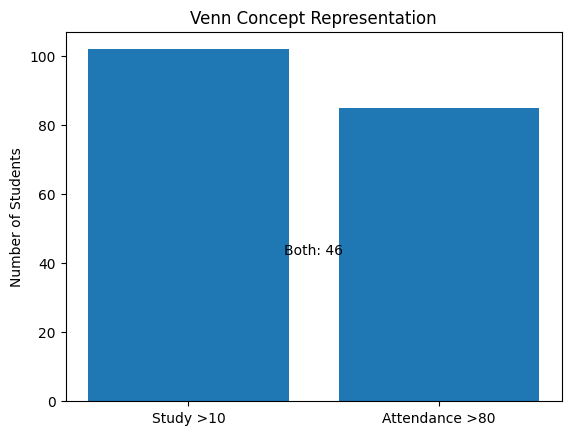

In [26]:
import matplotlib.pyplot as plt

A = len(df[df['study_hours'] > 10])
B = len(df[df['attendance'] > 80])
A_and_B = len(df[(df['study_hours'] > 10) & (df['attendance'] > 80)])

labels = ['Study >10', 'Attendance >80']
values = [A, B]

plt.bar(labels, values)
plt.title("Venn Concept Representation")
plt.ylabel("Number of Students")

# show intersection
plt.text(0.5, min(values)/2, f"Both: {A_and_B}", ha='center')

plt.show()

In [28]:
table = pd.crosstab(df['group_discussion'], df['final_exam_pass'])
table

final_exam_pass,Fail,Pass
group_discussion,,
No,76,31
Yes,65,28


In [29]:
joint = table.loc['Yes', 'Pass'] / len(df)
print(joint)

0.14


In [30]:
marginal = table['Pass'].sum() / len(df)
print(marginal)

0.295


In [31]:
conditional = table.loc['Yes', 'Pass'] / table.loc['Yes'].sum()
print(conditional)

0.3010752688172043


In [32]:
P_pass = pass_prob
P_fail = 1 - P_pass

P_high_given_pass = 0.70
P_high_given_fail = 0.40

P_high = (P_high_given_pass * P_pass) + (P_high_given_fail * P_fail)

bayes = (P_high_given_pass * P_pass) / P_high

print(bayes)

0.316213882719636
